In [44]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
df = pd.read_csv('https://raw.githubusercontent.com/JohnEric-Creator/FreeDataScienceAcquisition/refs/heads/main/Titanic-Dataset.csv')
print(df)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

In [46]:
# Data cleaning de NaN
# Ajustando valores NaN da coluna Age com fillna
# df['Age'].fillna(df['Age'].median(), inplace=True)
df['Age'] = df['Age'].fillna(df['Age'].median())

In [47]:
# Data cleaning de NaN
# Dropar as linhas (registros) que tem NaN nas colunas Fare ou Embarked
df = df.dropna(subset=['Fare', 'Embarked'])

In [48]:
# Engenharia de atributos (features engineering)
# Características derivadas
df['Family'] = df['SibSp'] + df['Parch'] + 1

In [49]:
# Engenharia de atributos (features engineering)
# Criação de variáveis dummies (one-hot enconding) da coluna Sex
df['Sex'] = df['Sex'].map({'male' : 1, 'female' : 0})

In [50]:
# Engenharia de atributos (features engineering)
# Criação de variáveis dummies (one-hot enconding) da coluna Embarked
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True, dtype=int)
df = pd.get_dummies(df, columns=['Pclass'], drop_first=True, dtype=int)
# df['Embarked_Q'] = df['Embarked_Q'].map({True : 1, False : 0})
# df['Embarked_S'] = df['Embarked_S'].map({True : 1, False : 0})

In [51]:
df['Age'].describe()

,Age
count,889.000000
mean,29.315152
std,12.984932
min,0.420000
25%,22.000000
50%,28.000000
75%,35.000000
max,80.000000


In [52]:
# Engenharia de atributos (features engineering)
# Discretização de variáveis contínuas (bins / intervalos) da coluna Age
bins = [0, 12, 18, 50, 100]
labels = ['Criança', 'Adolescente', 'Adulto', 'Idoso']
df['faixaEtaria'] = pd.cut(x=df['Age'], bins=bins, labels=labels)
df = pd.get_dummies(df, columns=['faixaEtaria'], drop_first=True, dtype=int)

In [53]:
# Engenharia de atributos (features engineering)
# Discretização de variáveis contínuas (bins / intervalos) da coluna Fare
bins = [0, 7.91, 14.54, 31, 512]
labels= ['Low', 'Mid-low', 'Mid-high', 'High']
df['faixaTarifas'] = pd.cut(x=df['Fare'], bins=bins, labels=labels)
df = pd.get_dummies(df, columns=['faixaTarifas'], drop_first=True, dtype=int)

In [54]:
df.columns

Index(['PassengerId', 'Survived', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Family', 'Embarked_Q', 'Embarked_S',
       'Pclass_2', 'Pclass_3', 'faixaEtaria_Adolescente', 'faixaEtaria_Adulto',
       'faixaEtaria_Idoso', 'faixaTarifas_Mid-low', 'faixaTarifas_Mid-high',
       'faixaTarifas_High'],
      dtype='object')

In [55]:
# Separar em conjuntos de entrada e saída (target ou alvo)
# Separar em varíaveis independentes (X) e dependentes (y ou target ou alvo)
X = df[['Sex', 'Family', 'Embarked_Q', 'Embarked_S', 'Pclass_2', 'Pclass_3',
        'faixaEtaria_Adolescente', 'faixaEtaria_Adulto', 'faixaEtaria_Idoso',
        'faixaTarifas_Mid-low', 'faixaTarifas_Mid-high', 'faixaTarifas_High']]
y = df['Survived']

In [56]:
# Separar os dados em treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [57]:
# Modelo de regressão logística para o dataset do Titanic
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [58]:
# Previsão dos dados do dataset do Titanic
y_pred = model.predict(X_test)
y_pred

array([0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       0])

In [59]:
# Métricas de avaliação do modelo
acuracia = accuracy_score(y_test, y_pred)
f1_score = f1_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f'Acurácia: {acuracia}')
print(f'F1-Score: {f1_score}')
print(f'Relatório:\n {report}')

Acurácia: 0.8089887640449438
F1-Score: 0.746268656716418
Relatório:
               precision    recall  f1-score   support

           0       0.89      0.81      0.85        58
           1       0.69      0.81      0.75        31

    accuracy                           0.81        89
   macro avg       0.79      0.81      0.80        89
weighted avg       0.82      0.81      0.81        89



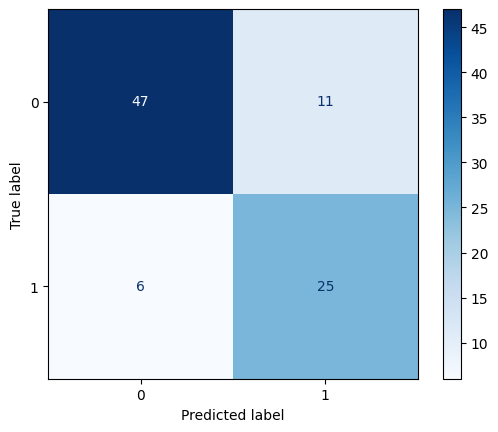

In [60]:
# Matrix de confusão
conf_matrix = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(conf_matrix, display_labels=model.classes_)
display.plot(cmap=plt.cm.Blues, values_format='g')
plt.show()

In [61]:
# Meus dados
X_test.columns

Index(['Sex', 'Family', 'Embarked_Q', 'Embarked_S', 'Pclass_2', 'Pclass_3',
       'faixaEtaria_Adolescente', 'faixaEtaria_Adulto', 'faixaEtaria_Idoso',
       'faixaTarifas_Mid-low', 'faixaTarifas_Mid-high', 'faixaTarifas_High'],
      dtype='object')

In [62]:
# Meus dados
my_dict = {
    'Sex' : 1,
    'Family' : 1,
    'Embarked_Q' : 0,
    'Embarked_S' : 0,
    'Pclass_2' : 0,
    'Pclass_3' : 0,
    'faixaEtaria_Adolescente' : 0,
    'faixaEtaria_Adulto' : 1,
    'faixaEtaria_Idoso' : 0,
    'faixaTarifas_Mid-low' : 0,
    'faixaTarifas_Mid-high' : 0,
    'faixaTarifas_High' : 1
}

nome = ['André']
my_test = pd.DataFrame(my_dict, index=nome)
print(my_test)

       Sex  Family  Embarked_Q  Embarked_S  Pclass_2  Pclass_3  \
André    1       1           0           0         0         0   

       faixaEtaria_Adolescente  faixaEtaria_Adulto  faixaEtaria_Idoso  \
André                        0                   1                  0   

       faixaTarifas_Mid-low  faixaTarifas_Mid-high  faixaTarifas_High  
André                     0                      0                  1  


In [63]:
# Previsão individual
y_pred = model.predict(my_test)
print(f'Sobreviveu? {y_pred}')

Sobreviveu? [1]
